In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import *

In [2]:
# Load dataset
ds = load_jsonl_file('./../datasets/MATE-dev/mm_0shot_llava_hfllava_1.5_7b_hf.jsonl')
nobjects=3
results_path = './results/llava7B/linear_probing/probe_image/'

# Filter dataset for a specific number of objects 
ds_ = [data for data in ds if data['object_count'] == nobjects]

5500it [00:00, 7935.06it/s] 


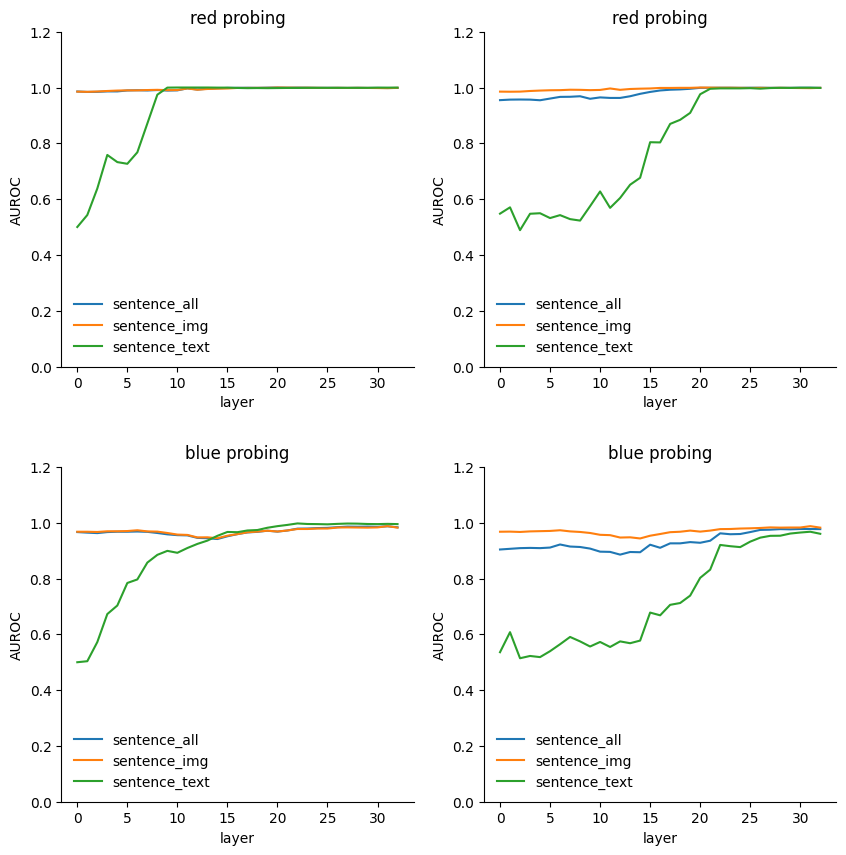

In [20]:
metric = 'auroc'
prompt_level = ['simple', 'complex']
task = ['color']
target_ls = ['red','blue']
nobjects = 3

fig,axs = plt.subplots(nrows=len(target_ls), ncols=len(prompt_level), figsize=(5*len(target_ls), 5*len(prompt_level)))


for idx, target in enumerate(target_ls):
    for jdx, prompt_type in enumerate(prompt_level):

        plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
        plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
    
        b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                        ax=axs[idx][jdx],
                        y=metric, x='layer', hue='embedding_level')
        b.set_title(f"{target} probing")
        b.set_ylabel(metric.upper())
        b.set(ylim=(0,1.2))
        
        b.legend(frameon=False)

    sns.despine(top=True, right=True)
    
    plt.subplots_adjust(hspace=0.3)



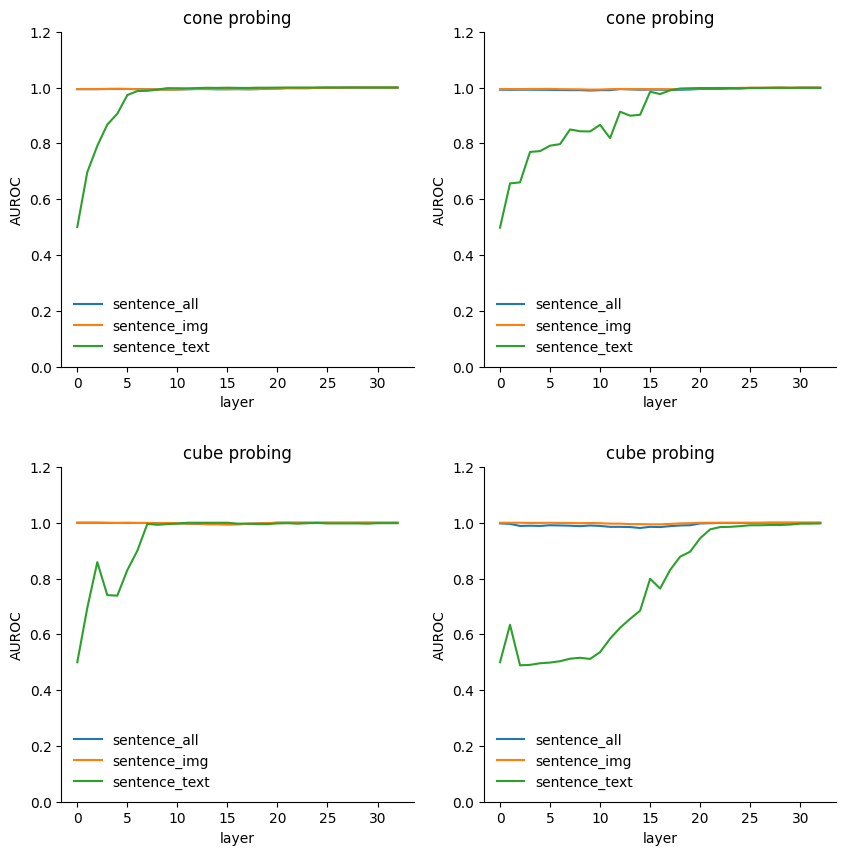

In [21]:
metric = 'auroc'
prompt_level = ['simple', 'complex']
task = ['shape']
target_ls = ['cone','cube']
nobjects = 3

fig,axs = plt.subplots(nrows=len(target_ls), ncols=len(prompt_level), figsize=(5*len(target_ls), 5*len(prompt_level)))


for idx, target in enumerate(target_ls):
    for jdx, prompt_type in enumerate(prompt_level):

        plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
        plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
    
        b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                        ax=axs[idx][jdx],
                        y=metric, x='layer', hue='embedding_level')
        b.set_title(f"{target} probing")
        b.set_ylabel(metric.upper())
        b.set(ylim=(0,1.2))
        
        b.legend(frameon=False)

    sns.despine(top=True, right=True)
    
    plt.subplots_adjust(hspace=0.3)



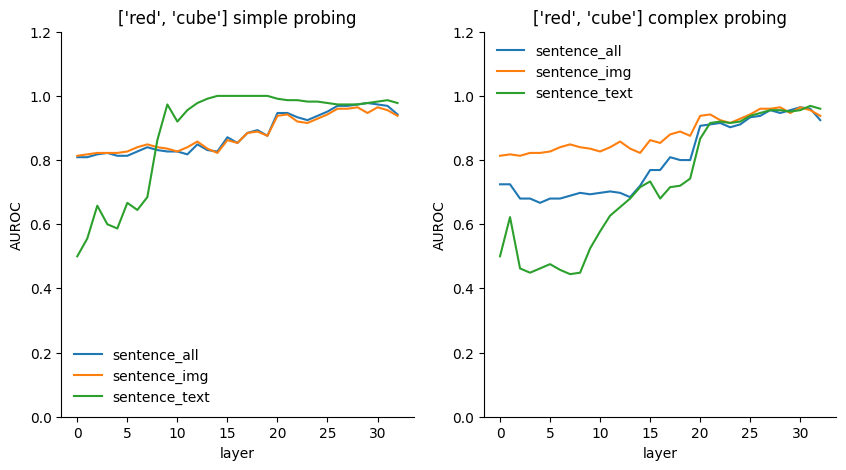

In [3]:
###### plot color probe results
task=['color', 'shape']
target=['red','cube']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'
prompt_level = ['simple','complex']


fig,axs = plt.subplots(1, len(prompt_level), figsize=(5*len(prompt_level), 5))

for idx, prompt_type in enumerate(prompt_level):
    plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{'_'.join(target)}_{nobjects}.csv", index_col=0)
    plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])

    b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                    ax=axs[idx],
                    y=metric, x='layer', hue='embedding_level')

    b.set_title(f"{target} {prompt_type} probing")
    b.set_ylabel(metric.upper())

    sns.despine(top=True, right=True)
    b.set(ylim=(0,1.2))
    b.legend(frameon=False)
    



sns.despine(top=True, right=True)

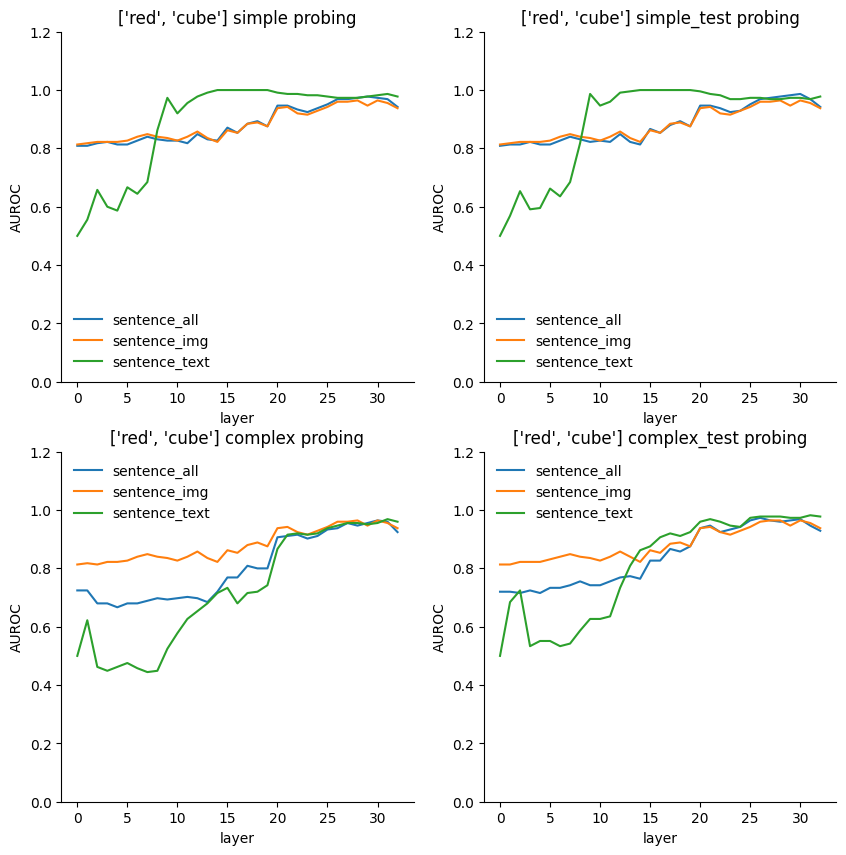

In [16]:
###### plot color probe results
task=['color', 'shape']
target=['red','cube']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'
version_ls = ['','_test']
prompt_level=['simple','complex']


fig,axs = plt.subplots(len(prompt_level), len(version_ls), figsize=(5*len(version_ls), 5*len(prompt_level)))

for idx, version in enumerate(version_ls):
    for jdx, prompt_type in enumerate(prompt_level):
        plot_df = pd.read_csv(f"{results_path}/{prompt_type}{version}/probing_results_{'_'.join(task)}_{'_'.join(target)}_{nobjects}.csv", index_col=0)
        plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
        plot_df['layer'] = list(range(33))*len(plot_df['embedding_level'].unique())
        b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                        ax=axs[jdx][idx],
                        y=metric, x='layer', hue='embedding_level')

        b.set_title(f"{target} {prompt_type}{version} probing")
        b.set_ylabel(metric.upper())

        sns.despine(top=True, right=True)
        b.set(ylim=(0,1.2))
        b.legend(frameon=False)
    



sns.despine(top=True, right=True)

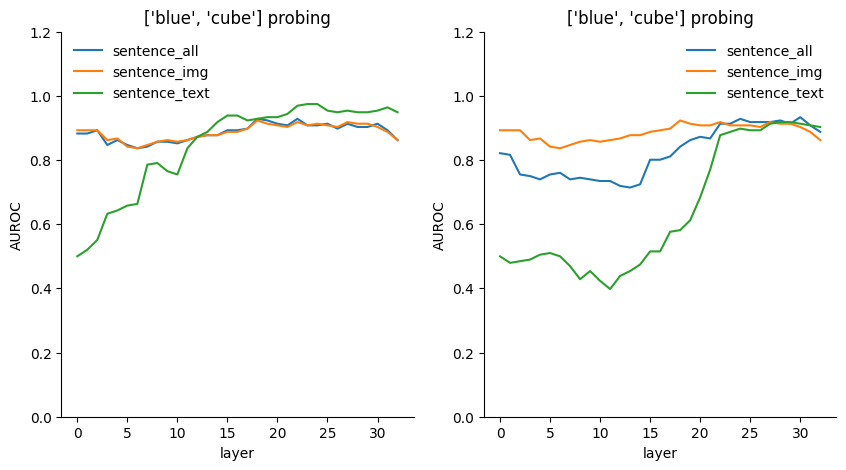

In [13]:
###### plot color probe results
task=['color', 'shape']
target=['blue','cube']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'
prompt_level = ['simple','complex']


fig,axs = plt.subplots(1, len(prompt_level), figsize=(5*len(prompt_level), 5))

for idx, prompt_type in enumerate(prompt_level):
    results_path = './results/llava7B/linear_probing/probe_image/'
    plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{'_'.join(target)}_{nobjects}.csv", index_col=0)
    plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])

    b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                    ax=axs[idx],
                    y=metric, x='layer', hue='embedding_level')
    b.set_title(f"{target} probing")
    b.set_ylabel(metric.upper())

    sns.despine(top=True, right=True)
    b.set(ylim=(0,1.2))
    b.legend(frameon=False)



sns.despine(top=True, right=True)

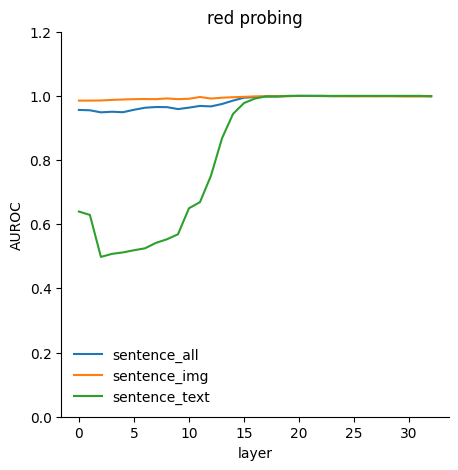

In [15]:
results_path = './results/llava7B/linear_probing/probe_image_and_text/'
metric = 'auroc'
prompt_level = ['complex']
task = ['color']
target_ls = ['red']
nobjects = 3

fig,axs = plt.subplots(nrows=len(target_ls), ncols=len(prompt_level), figsize=(5*len(target_ls), 5*len(prompt_level)))


for idx, target in enumerate(target_ls):
    for jdx, prompt_type in enumerate(prompt_level):

        plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
        plot_df['layer'] = list(range(33))*6
        plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
        
    
        b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                        ax=axs,
                        y=metric, x='layer', hue='embedding_level')
        b.set_title(f"{target} probing")
        b.set_ylabel(metric.upper())
        b.set(ylim=(0,1.2))
        
        b.legend(frameon=False)

    sns.despine(top=True, right=True)
    
    plt.subplots_adjust(hspace=0.3)



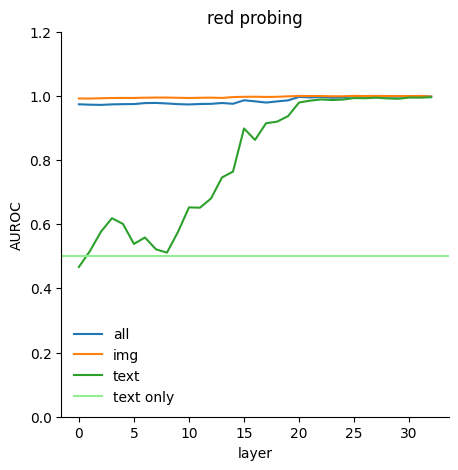

In [36]:
results_path = './results/llava7B/linear_probing/archive/image/'
metric = 'auroc'
prompt_level = ['']
task = ['color']
target_ls = ['red']
nobjects = 3

fig,axs = plt.subplots(nrows=len(target_ls), ncols=len(prompt_level), figsize=(5*len(target_ls), 5*len(prompt_level)))


for idx, target in enumerate(target_ls):
    for jdx, prompt_type in enumerate(prompt_level):

        plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
        plot_df['layer'] = list(range(33))*6
        plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
        plot_df['hue'] = [i.split('_')[1] for i in plot_df['embedding_level']]
    
        b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                        ax=axs,
                        y=metric, x='layer', hue='hue')
        b.axhline(y=0.5, color='lightgreen', label='text only')
        b.set_title(f"{target} probing")
        b.set_ylabel(metric.upper())
        b.set(ylim=(0,1.2))
        
        b.legend(frameon=False)

    sns.despine(top=True, right=True)
    
    plt.subplots_adjust(hspace=0.3)



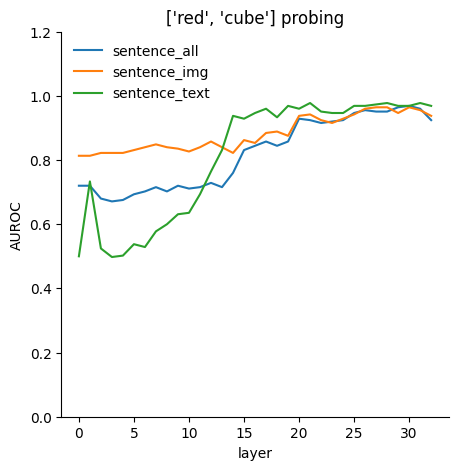

In [22]:
results_path = './results/llava7B/linear_probing/probe_image_and_text/'
metric = 'auroc'
prompt_level = ['complex']
task_ls = ['color','shape']
target_ls = ['red','cube']
nobjects = 3

fig,axs = plt.subplots(nrows=1, ncols=1, figsize=(5,5))


plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task_ls)}_{'_'.join(target_ls)}_{nobjects}.csv")
plot_df['layer'] = list(range(33))*6
plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])


b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                ax=axs,
                y=metric, x='layer', hue='embedding_level')
b.set_title(f"{target_ls} probing")
b.set_ylabel(metric.upper())
b.set(ylim=(0,1.2))

b.legend(frameon=False)

sns.despine(top=True, right=True)

plt.subplots_adjust(hspace=0.3)



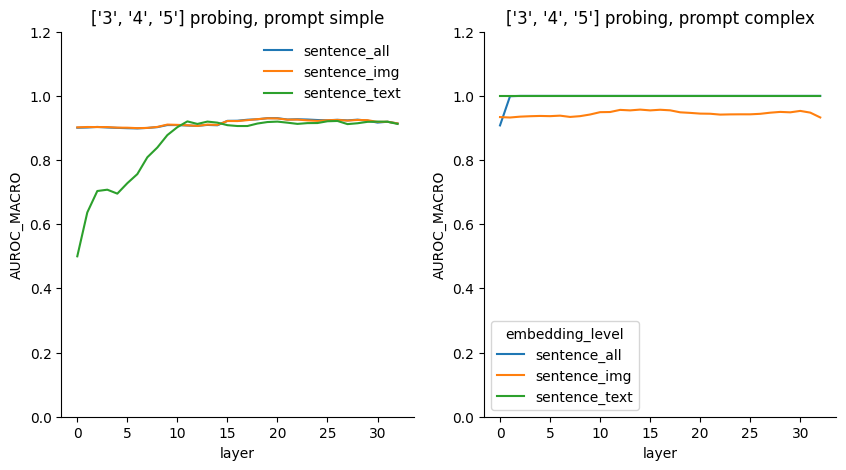

In [6]:

results_path = './results/llava7B/linear_probing/probe_count/'
metric = 'auroc_macro'
prompt_level = ['simple', 'complex']
task = ['count']
target_ls = ['3','4', '5']

fig,axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

plot_df = pd.read_csv(f"{results_path}/{prompt_level[0]}/probing_results_{'_'.join(task)}_{'_'.join(target_ls)}.csv")
plot_df['layer'] = list(range(33))*3
plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])


b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                ax=axs[0],
                y=metric, x='layer', hue='embedding_level')
b.set_title(f"{target_ls} probing, prompt {prompt_level[0]}")
b.set_ylabel(metric.upper())
b.set(ylim=(0,1.2))

b.legend(frameon=False)

plot_df = pd.read_csv(f"{results_path}/{prompt_level[1]}/probing_results_{'_'.join(task)}_{'_'.join(target_ls)}.csv")
plot_df['layer'] = list(range(33))*3
plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])


b = sns.lineplot(data=plot_df[plot_df['embedding over']=='sentence'], 
                ax=axs[1],
                y=metric, x='layer', hue='embedding_level')
b.set_title(f"{target_ls} probing, prompt {prompt_level[1]}")
b.set_ylabel(metric.upper())
b.set(ylim=(0,1.2))

sns.despine(top=True, right=True)

plt.subplots_adjust(hspace=0.3)

